In [3]:
!pip install -U crawl4ai
!playwright install chromium --with-deps

In [5]:
!playwright install chromium --with-deps

In [7]:
 # Jupyter already runs an event loop; this lets await work in cells

import asyncio
from crawl4ai import AsyncWebCrawler, CrawlerRunConfig, CacheMode
from crawl4ai.content_filter_strategy import PruningContentFilter, BM25ContentFilter
from crawl4ai.markdown_generation_strategy import DefaultMarkdownGenerator

In [8]:
import asyncio
from crawl4ai import AsyncWebCrawler, CrawlerRunConfig, CacheMode
from crawl4ai.content_filter_strategy import PruningContentFilter, BM25ContentFilter
from crawl4ai.markdown_generation_strategy import DefaultMarkdownGenerator



In [12]:
async def try_url(url: str, threshold: float = 0.48):
    md_generator = DefaultMarkdownGenerator(
        content_filter=PruningContentFilter(threshold=threshold, threshold_type="fixed", min_word_threshold=0)
    )
    config = CrawlerRunConfig(cache_mode=CacheMode.BYPASS, markdown_generator=md_generator)

    async with AsyncWebCrawler() as crawler:
        result = await crawler.arun(url=url, config=config)

    print(f"success: {result.success}")
    print(f"raw_markdown length:  {len(result.markdown.raw_markdown)}")
    print(f"fit_markdown length:  {len(result.markdown.fit_markdown)}")
    print("\n--- fit_markdown preview (first 800 chars) ---")
    print(result.markdown)
    print("\n--- raw_markdown preview (first 800 chars) ---")
    print(result.markdown)
    return result


In [13]:
result = await try_url("https://www.omnibound.ai/")

[INIT].... → Crawl4AI 0.9.3 

[FETCH]... ↓ https://www.omnibound.ai/                                                                            | ✓ | ⏱: 1.94s 

[SCRAPE].. ◆ https://www.omnibound.ai/                                                                            | ✓ | ⏱: 0.06s 

[COMPLETE] ● https://www.omnibound.ai/                                                                            | ✓ | ⏱: 2.01s 

success: True
raw_markdown length:  17308
fit_markdown length:  7290

--- fit_markdown preview (first 800 chars) ---
**Free AI Search Visibility Checker |** See how AI-ready you are and where you stand in AI search.  [Check My Score](https://www.omnibound.ai/ai-search-visibility-checker)
×
[Skip to main content](https://www.omnibound.ai/#main-content)
[ ![Omnibound - AI Search Marketing Platform](https://www.omnibound.ai/hubfs/raw_assets/public/Omnibound-Website%20Theme%20Dec%202025/images/Logo.svg) ](https://www.omnibound.ai/)
  * Platform ![](https://www.omnibound.ai/hubfs/raw_assets/public/Omnibound-Website%20Theme/images/Vector.svg)
Product
[ AI Search Intelligence Track where your brand wins or loses in AI search→ ](https://www.omnibound.ai/ai-search-intelligence) [ Audit & Optimize Fix what’s not getting cited and improve content performance→ ](https://www.omnibound.ai/content-audit-and-optimization) [ Marketing Context Living research that stays current as context evolves→ ](htt

In [ ]:
async def try_url_raw(url: str):
    # No content_filter passed at all — this is Crawl4AI's own DOM cleanup only
    # (scripts, styles, comments stripped) with NO pruning/BM25/LLM filtering on top
    config = CrawlerRunConfig(cache_mode=CacheMode.BYPASS)

    async with AsyncWebCrawler() as crawler:
        result = await crawler.arun(url=url, config=config)

    print(f"success: {result.success}")
    print(f"cleaned_html length: {len(result.cleaned_html)}")
    print(f"raw_markdown length: {len(result.markdown.raw_markdown)}")
    print(f"fit_markdown length: {len(result.markdown.fit_markdown)}")  # will equal raw if no filter set
    return result

result = await try_url_raw("https://www.omnibound.ai/")
print(result.markdown.raw_markdown)  # the FULL thing, not a preview — read all of it

[INIT].... → Crawl4AI 0.9.3 

[FETCH]... ↓ https://www.omnibound.ai/                                                                            | ✓ | ⏱: 2.18s 

[SCRAPE].. ◆ https://www.omnibound.ai/                                                                            | ✓ | ⏱: 0.02s 

[COMPLETE] ● https://www.omnibound.ai/                                                                            | ✓ | ⏱: 2.21s 

success: True
cleaned_html length: 72893
raw_markdown length: 17308
fit_markdown length: 0
**Free AI Search Visibility Checker |** See how AI-ready you are and where you stand in AI search.  [Check My Score](https://www.omnibound.ai/ai-search-visibility-checker)
×
[Skip to main content](https://www.omnibound.ai/#main-content)
[ ![Omnibound - AI Search Marketing Platform](https://www.omnibound.ai/hubfs/raw_assets/public/Omnibound-Website%20Theme%20Dec%202025/images/Logo.svg) ](https://www.omnibound.ai/)
  * Platform ![](https://www.omnibound.ai/hubfs/raw_assets/public/Omnibound-Website%20Theme/images/Vector.svg)
Product
[ AI Search Intelligence Track where your brand wins or loses in AI search→ ](https://www.omnibound.ai/ai-search-intelligence) [ Audit & Optimize Fix what’s not getting cited and improve content performance→ ](https://www.omnibound.ai/content-audit-and-optimization) [ Marketing Context Living research that stays current as context evolves→ ](https://www.omnibound.ai/b2b-

In [15]:
!crawl4ai-setup

[INIT].... → Running post-installation setup... 
[INIT].... → Installing Playwright browsers... 
182.1 MiB [                    ] 0% 0.0s182.1 MiB [                    ] 0% 350.8s182.1 MiB [                    ] 0% 373.5s182.1 MiB [                    ] 0% 1046.0s182.1 MiB [                    ] 0% 877.7s182.1 MiB [                    ] 0% 1196.3s182.1 MiB [                    ] 0% 1049.2s182.1 MiB [                    ] 0% 955.8s182.1 MiB [                    ] 0% 879.9s182.1 MiB [                    ] 0% 816.9s182.1 MiB [                    ] 0% 822.5s182.1 MiB [                    ] 0% 759.6s182.1 MiB [                    ] 0% 729.9s182.1 MiB [                    ] 0% 702.4s182.1 MiB [                    ] 0% 677.9s182.1 MiB [                    ] 0% 653.6s182.1 MiB [                    ] 0% 629.4s182.1 MiB [                    ] 0% 609.5s182.1 MiB [                    ] 0% 588.5s182.1 MiB [                    ] 0% 571.6s182.1 MiB [                    ] 0% 552.2s182.1 MiB [         

In [16]:
from crawl4ai import AsyncWebCrawler

crawler = AsyncWebCrawler()

result = await crawler.arun(
    url="https://www.omnibound.ai/"
)

print("Success:", result.success)
print("URL:", result.url)
print("Title:", result.metadata.get("title"))

print("\n--- MARKDOWN ---\n")
print(result.markdown)

[INIT].... → Crawl4AI 0.9.3 

[FETCH]... ↓ https://www.omnibound.ai/                                                                            | ✓ | ⏱: 2.32s 

[SCRAPE].. ◆ https://www.omnibound.ai/                                                                            | ✓ | ⏱: 0.02s 

[COMPLETE] ● https://www.omnibound.ai/                                                                            | ✓ | ⏱: 2.35s 

Success: True
URL: https://www.omnibound.ai/
Title: AI Search Visibility and Growth Platform | Omnibound

--- MARKDOWN ---

**Free AI Search Visibility Checker |** See how AI-ready you are and where you stand in AI search.  [Check My Score](https://www.omnibound.ai/ai-search-visibility-checker)
×
[Skip to main content](https://www.omnibound.ai/#main-content)
[ ![Omnibound - AI Search Marketing Platform](https://www.omnibound.ai/hubfs/raw_assets/public/Omnibound-Website%20Theme%20Dec%202025/images/Logo.svg) ](https://www.omnibound.ai/)
  * Platform ![](https://www.omnibound.ai/hubfs/raw_assets/public/Omnibound-Website%20Theme/images/Vector.svg)
Product
[ AI Search Intelligence Track where your brand wins or loses in AI search→ ](https://www.omnibound.ai/ai-search-intelligence) [ Audit & Optimize Fix what’s not getting cited and improve content performance→ ](https://www.omnibound.ai/content-audit-and-optimization) [ Marketing Context Living research that stays current as context evolves

In [17]:
print(type(result))

print(result.__dict__.keys())

<class 'crawl4ai.models.CrawlResultContainer'>
dict_keys(['_results'])


In [18]:
print("Success:", result.success)
print("Error:", result.error_message)
print("Final URL:", result.url)
print("Title:", result.metadata.get("title"))

Success: True
Error: 
Final URL: https://www.omnibound.ai/
Title: AI Search Visibility and Growth Platform | Omnibound


In [19]:
print("HTML length:", len(result.html or ""))
print("Markdown length:", len(result.markdown.raw_markdown or ""))
print("Fit Markdown length:", len(result.markdown.fit_markdown or ""))

HTML length: 219805
Markdown length: 17308
Fit Markdown length: 0


In [20]:
raw = result.markdown.raw_markdown
fit = result.markdown.fit_markdown

print("RAW MARKDOWN")
print("=" * 80)
print(raw)

print("\n\nFIT MARKDOWN")
print("=" * 80)
print(fit)

RAW MARKDOWN
**Free AI Search Visibility Checker |** See how AI-ready you are and where you stand in AI search.  [Check My Score](https://www.omnibound.ai/ai-search-visibility-checker)
×
[Skip to main content](https://www.omnibound.ai/#main-content)
[ ![Omnibound - AI Search Marketing Platform](https://www.omnibound.ai/hubfs/raw_assets/public/Omnibound-Website%20Theme%20Dec%202025/images/Logo.svg) ](https://www.omnibound.ai/)
  * Platform ![](https://www.omnibound.ai/hubfs/raw_assets/public/Omnibound-Website%20Theme/images/Vector.svg)
Product
[ AI Search Intelligence Track where your brand wins or loses in AI search→ ](https://www.omnibound.ai/ai-search-intelligence) [ Audit & Optimize Fix what’s not getting cited and improve content performance→ ](https://www.omnibound.ai/content-audit-and-optimization) [ Marketing Context Living research that stays current as context evolves→ ](https://www.omnibound.ai/b2b-marketing-context-engine)
Hidden
[ Citation-Worthy Content Create content that

In [4]:
from langgraph.graph import END, START, StateGraph
from typing import TypedDict


class QAState(TypedDict):
    question: str
    retry_count: int


def build_ask_graph():
    workflow = StateGraph(QAState)

    # Placeholder nodes — only needed to visualize the graph
    workflow.add_node("retrieve", lambda state: state)
    workflow.add_node("grade", lambda state: state)
    workflow.add_node("rewrite", lambda state: state)
    workflow.add_node("answer", lambda state: state)
    workflow.add_node("not_in_corpus", lambda state: state)

    # Start
    workflow.add_edge(START, "retrieve")

    # Main flow
    workflow.add_edge("retrieve", "grade")

    # Conditional routing
    workflow.add_conditional_edges(
        "grade",
        lambda state: "answer",
        {
            "answer": "answer",
            "rewrite": "rewrite",
            "not_in_corpus": "not_in_corpus",
        },
    )

    # Retry path
    workflow.add_edge("rewrite", "retrieve")

    # End states
    workflow.add_edge("answer", END)
    workflow.add_edge("not_in_corpus", END)

    return workflow.compile()


graph = build_ask_graph()



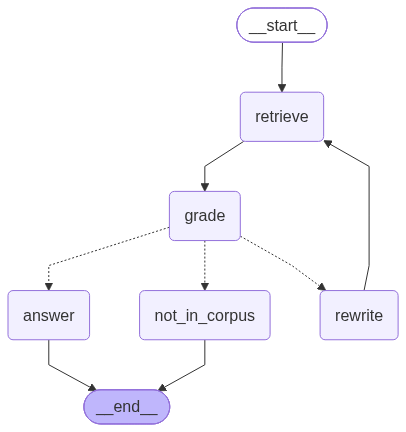

In [5]:
graph

In [ ]:
# Generate Mermaid diagram
mermaid = graph.get_graph().draw_mermaid()

print(mermaid)